# Project: Titanic EDA
# Titanic Data
## Introduction
### This dataset contains demographics and passenger information from 891 of the 2224 passengers and crew on board the Titanic. You can view a description of this dataset on the Kaggle website (https://www.kaggle.com/c/titanic), where the data was obtained.

#### Data Dictionary
* survival: Survival (0 = No, 1 = Yes)
* pclass: Ticket class(1 = 1st, 2 = 2nd, 3 = 3rd)
* sex: Sex
* Age: Age in years
* sibsp: Number of siblings/spouses aboard the Titanic
* parch: Number of parents/children aboard the Titanic
* ticket: Ticket number
* fare: Passenger fare
* cabin: Cabin number
* embarked:Port of Embarkation(C = Cherbourg, Q = Queenstown, S = Southampton)

# We analyse some of the questions 
* Who were the passengers on the Titanic? (age, gender, class.. etc)
* What deck were the passengers on and how does that relate to their class?
* Where did the passengers come from?
* Who was alone and who was with family?
* What factors helped someone survive the sinking?

In [1]:
# importing  required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## import the titanic Dataset using Pandas from Github for EDA 

In [2]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv') # get the data from github 

In [3]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In titanic dataframe 891 rows and 12 columns are present 

Using the info() check the some important information like the dtype of columns and null value are persent in columns  

In [4]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


we check statics values of numeric columns 

remove unnessacery column from dataframe


In [6]:
titanic.drop(['PassengerId'], axis =1, inplace = True)

In [7]:
titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

## In columns Age and Embarked, present null rows 

## using static values to fill null rows of columns


## In the 'Age' column, it is highly possible that some of childs ages are not mentioned in the dataframe, so we can fill null rows to avrage age of children below 16 age childan's ##

In [8]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median(), inplace = True)

In [9]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode(), inplace = True)

# Set the Name column as the index of dataframe


In [10]:
titanic.set_index(titanic['Name'], inplace = True)

In [11]:
def whos(df):
    age = df['Age']
    sex = df['Sex']
    return 'child' if age <= 16 else sex

In [12]:
titanic['Whos'] = titanic.apply(whos, axis = 1)


### Add a new column 'Whos'.
    
#### In this column, passengers are separated by child and adult categories, and drop the 'Sex' column

In [13]:
titanic.drop('Sex', inplace = True, axis = 1)

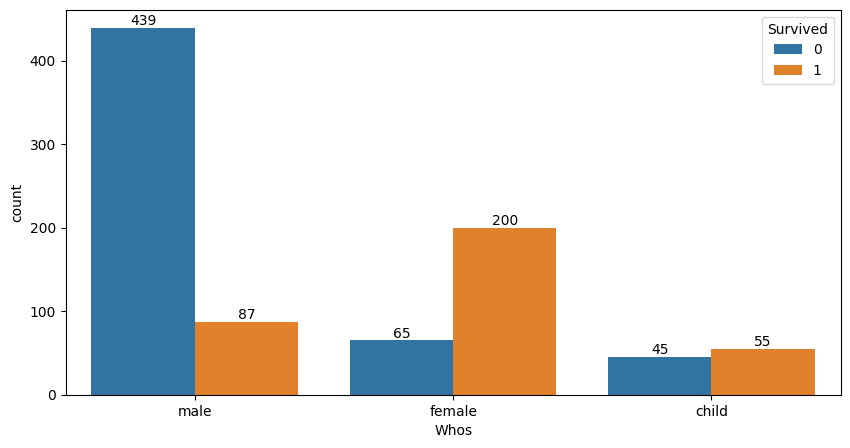

In [34]:
plt.figure(figsize=(10,5)) # create page for plot
ax  = sns.countplot(titanic, x = 'Whos', hue = 'Survived' ) # make bar plot using seaborn
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show() 


### In the graph given above, it is observed that passengers are divided into 3 categories.
* Male
* Female
* Child
### female passengers are more likely to survive compared with male passengers

# Who were the passengers on the Titanic? (age, gender, class.. etc)


In [15]:
titanic[['Age','Whos','Pclass','Survived']]

,Age,Whos,Pclass,Survived
Name,,,,
"Braund, Mr. Owen Harris",22.0,male,3,0
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.0,female,1,1
"Heikkinen, Miss. Laina",26.0,female,3,1
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,1,1
"Allen, Mr. William Henry",35.0,male,3,0
...,...,...,...,...
"Montvila, Rev. Juozas",27.0,male,2,0
"Graham, Miss. Margaret Edith",19.0,female,1,1
"Johnston, Miss. Catherine Helen ""Carrie""",28.0,female,3,0


# What deck were the passengers on and how does that relate to their class?


In [16]:
titanic['Deck'] = titanic['Cabin'].str[0]

In [17]:
titanic.drop('Cabin', axis = 1, inplace = True)

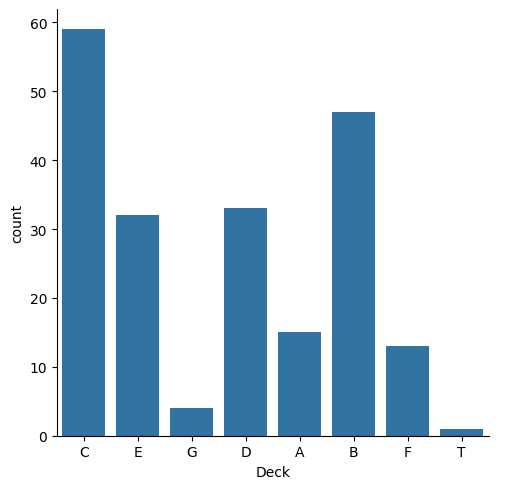

In [18]:
ax = sns.catplot(x= 'Deck', data = titanic, kind= 'count')
plt.show()

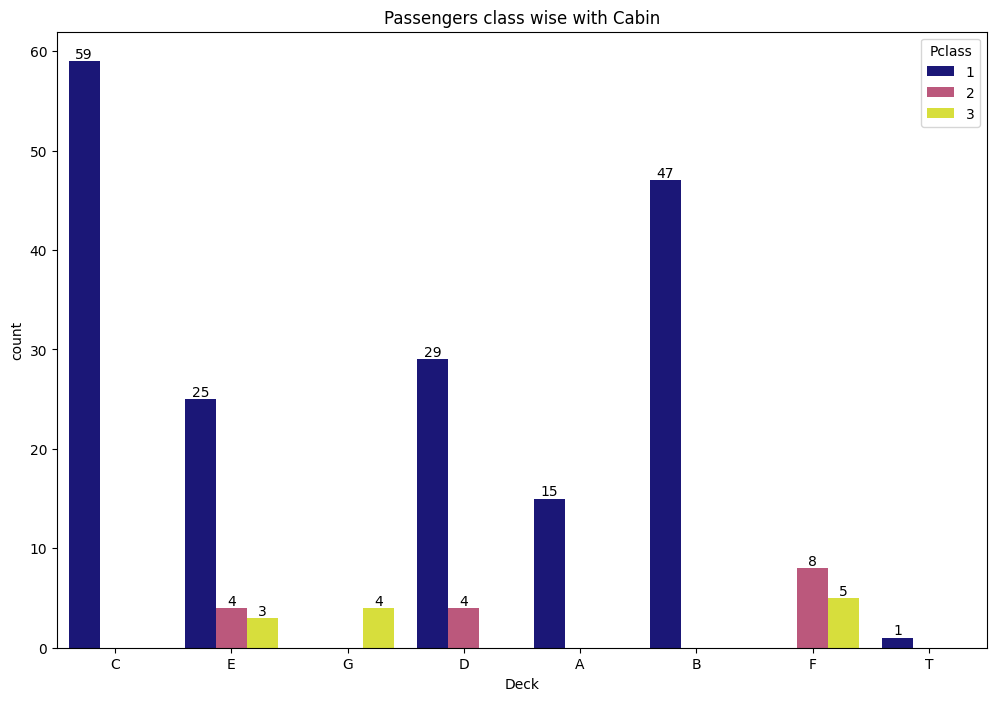

In [19]:
plt.figure(figsize=(12,8))
plt.title('Passengers class wise with Cabin')
ax = sns.countplot(titanic, x = 'Deck', hue = 'Pclass', palette='plasma' )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
plt.show()

### In the pclass column, economically statue define 1 means upper class, 2 means middle class, and 3 means lower class

#### In the graph given above, it is observed that most of the passengers in the 1st class belong to deck C, B, and A


In [20]:
# We add a new column, Family. In that column, we check who was alone and who was with family 
titanic['Family'] = titanic['SibSp'] + titanic['Parch']


In [21]:
#in column family value = 0 means that the passenger was along
def along_pas(passenger):
    family = passenger['Family']
    return 'alone' if family ==0 else 'with family'

In [22]:
titanic['Family'] = titanic.apply(along_pas, axis = 1)

# Who was alone and who was with family?


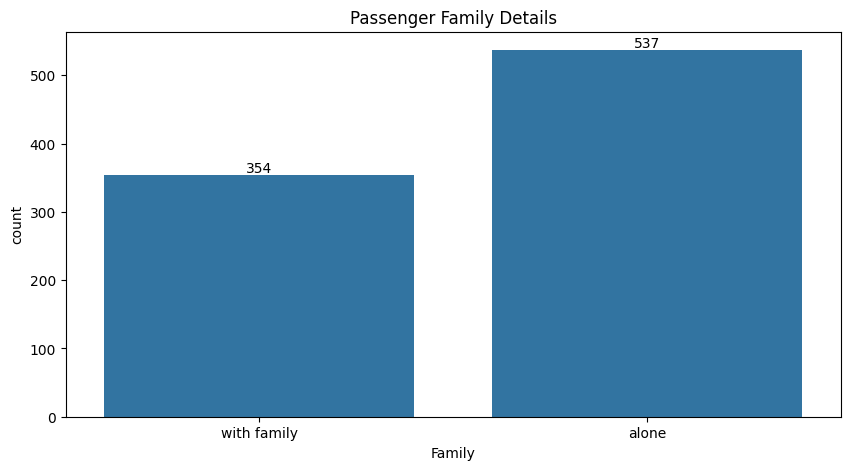

In [23]:
plt.figure(figsize=(10, 5))
plt.title('Passenger Family Details')
ax = sns.countplot(titanic, x= 'Family', )
ax.bar_label(ax.containers[0])
plt.show()

### In the graph given above, we see that most of the passengers was traving alone 
### In the graph given below, we separete the passengers by gender and Age basis. and seen maximun number of the male passengers are travling alone  

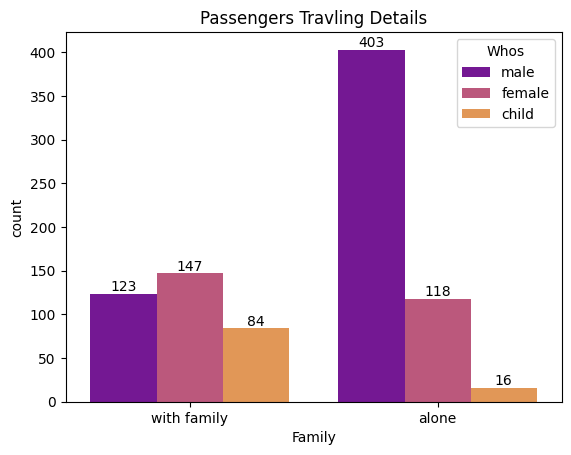

In [24]:
plt.title('Passengers Travling Details')
ax = sns.countplot(titanic, x= 'Family', hue = 'Whos', palette='plasma')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
plt.show()

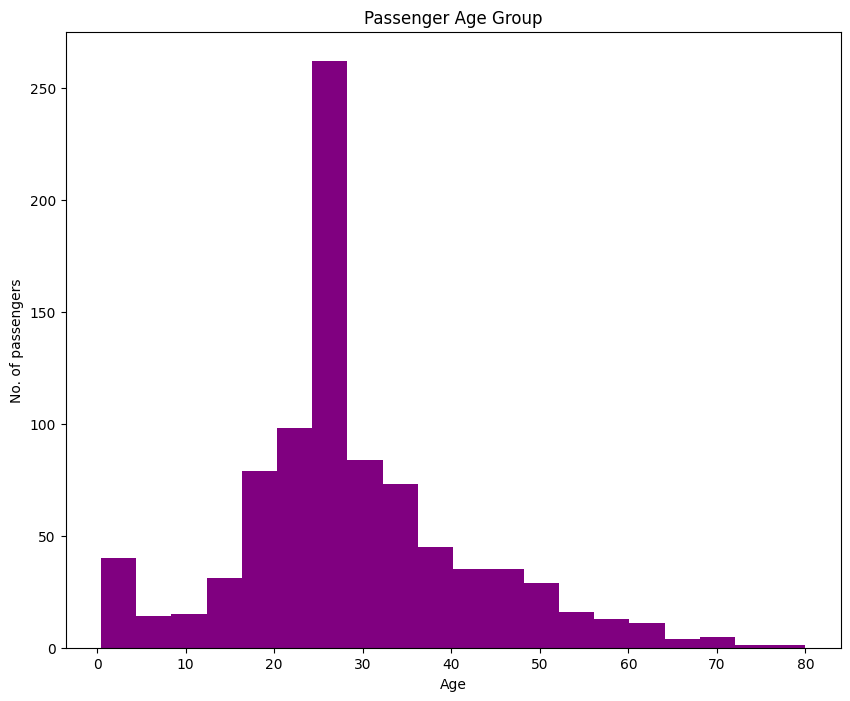

In [25]:
plt.figure(figsize=(10,8))
titanic['Age'].hist(bins = 20, color = 'purple', grid = False)
plt.title('Passenger Age Group')
plt.xlabel('Age')
plt.ylabel('No. of passengers')
plt.show()


## In the Graph given above, we see that most of the passengers were very young on the Titanic. 
### only 1 passenger age 80 year old who was on the Titanic 
### maximun number of passenger was belong Age group 22 to 32 year. 

# Where did the passengers come from?


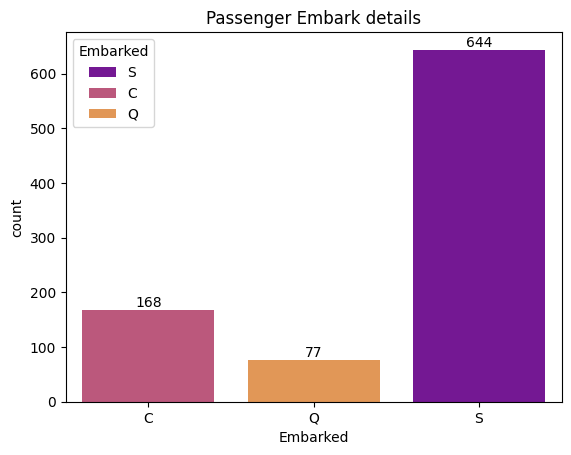

In [26]:
plt.figure()
ax = sns.countplot(titanic, x= 'Embarked', order = ['C', 'Q','S'], hue = 'Embarked' , palette = 'plasma' )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
plt.title('Passenger Embark details')
plt.show()


## Port of Embarkation(C = Cherbourg, Q = Queenstown, S = Southampton)
### In the graph given above, it is observed that most of the passengers embarked from Southampton


# Where did the passengers come from and who was survived


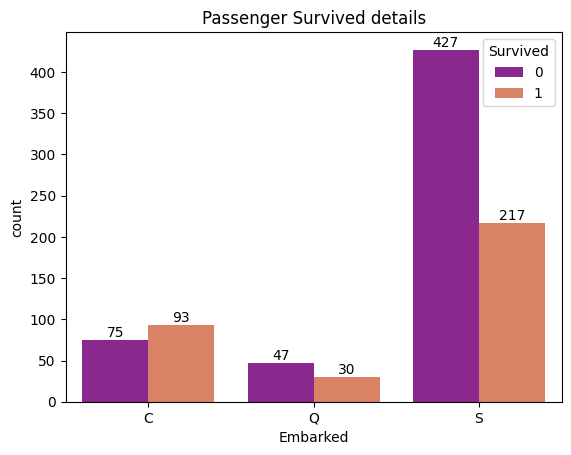

In [36]:
plt.figure()
ax = sns.countplot(titanic, x= 'Embarked', order = ['C', 'Q','S'], hue = 'Survived' , palette = 'plasma' )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Passenger Survived details')
plt.savefig('My_fig')
plt.show()


## survival: Survival (0 = No, 1 = Yes)
### In the graph given above, we see that most of the passengers were from sounthamtom so the number of people who survived from this town was maximum
